# Computation of Greeks using Malliavin Calculus

This section offers a brief introduction to Malliavin calculus and its applications to mathematical finance, in particular to computation of the Greeks by the Monte Carlo method. The simplest way to compute sensitivities of an option by Monte Carlo method consists in approximating the derivatives by incremental ratios obtained by simulating the payoffs corresponding to close values of the underlying asset, the so called finite differences method.
If the payoff function is *not regular* (for example, in the case of a digital option with strike $K$ and payoff function $\mathbb{1}_{[K,+\infty[}$) this technique is not efficient since the incremental ratio has typically a very large variance. The problem can be solved by integrating by parts and differentiating the density function of the underlying asset, provided it is sufficiently regular: if the underlying asset follows a geometric Brownian motion, this is possible since the explicit expression of the density is known. In a more general setting, the Malliavin calculus allows obtaining explicit integration-by-parts formulas even if the density of the underlying asset is not known and so it provides an effective tool to approximate the Greeks numerically.

The applications of Malliavin calculus to mathematical finance are relatively recent: Malliavin's result initially attracted great interest in view of the proof and extension of Hörmander's hypoellipticity theorem. From a theoretical point of view, a remarkable financial application is the Clark-Ocone formula, that improves the martingale representation theorem and allows expressing the hedging strategy of an option in terms of the stochastic derivative of its price. We also recall that Malliavin calculus was recently used to approximate numerically the price of American options by the Monte Carlo method.

We give some basic ideas of Malliavin calculus by analyzing several examples of the applications to the computation of the Greeks. We confine ourselves to the one-dimensional case, choosing simplicity instead of generality.

## Integration by parts and computation of the Greeks

In this part we prove a stochastic integration-by-parts formula and by means of some remarkable examples, we illustrate its application to the computation of the Greeks by the Monte Carlo method. As we have already said in the introduction, these techniques can be effective also when *poor regularity properties* are assumed on the payoff function $F$, i.e. just where the direct application of the Monte Carlo method gives unsatisfactory results, even if the underlying asset follows a simple geometric Brownian motion.

The stochastic integration by parts allows removing the derivatives of the payoff function, thus improving the numerical approximation: more precisely, let us suppose that we want to determine $\partial_\alpha\mathbb{E}[F(S_T)Y]$ where $S_T$ denotes the final price of the underlying asset depending on a parameter $\alpha$ and $Y$ is some random variable (e.g. a discount factor). The idea is to try to express $\partial_\alpha F(S_T)Y$ in the form
$$
\int_0^T D_s F(S_T)YU_s \,ds,
$$
for some adapted integrable process $U$. By using the duality relation, formally we obtain
$$
\partial_\alpha\mathbb{E}[F(S_T)Y]=\mathbb{E}[F(S_T)D^*(YU)],
$$
that, as we shall see in the following examples, can be used to get a good numerical approximation. Since we want to show how to apply a technique rather than dwelling on the mathematical detail, the presentation will be somewhat informal.

**Theorem (Stochastic integration by parts)**

Let $F\in C_b^1$ and let $X\in\mathbb{D}^{1,2}$. Then the following integration by parts holds:
$$
\mathbb{E}[F'(X)Y]=\mathbb{E}\left[F(X)\int_0^T\frac{u_t Y}{\int_0^T u_s D_s X ds}\diamond\,dW_t\right],
$$
for every random variable $Y$ and for every stochastic process $u$ for which it is well-defined.

**Proof (sketch)**

By the chain rule we have
$$
D_t F(X) = F'(X)D_tX.
$$
Multiplying by $u_t Y$ and integrating from $0$ to $T$ we get
$$
\int_0^T u_t Y D_t F(X)\,dt = F'(X)Y \int_0^T u_t D_t X\,dt,
$$
whence, provided that
$$
\frac{1}{\int_0^T u_t D_t X\,dt}
$$
has good integrability properties, we have
$$
F'(X)Y = \int_0^T D_t F(X)\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\,dt.
$$
Taking the mean and by the duality relation we have
$$
\mathbb{E}[F'(X)Y] = \mathbb{E}\left[\int_0^T D_t F(X)\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\,dt\right]=\mathbb{E}\left[F(X)\int_0^T\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\diamond \,dW_t\right].
$$
<div style="text-align: right;">$\square\qquad\qquad$</div>

The regularity assumptions on the function $F$ can be greatly weakened: by using a standard regularization procedure, it is possible to prove the validity of the integration-by-parts formula for weakly differentiable (or even differentiable in a distributional sense) functions.

The process $u$ in the formula can be often chosen in a suitable way in order to simplify the expression of the integral on the right-hand side. If $u=1$ and $Y=\partial_\alpha X$, the integration-by-parts formula becomes
$$
\partial_\alpha \mathbb{E}[F(X)]=\mathbb{E}[F'(X)\partial_\alpha X]=\mathbb{E}\left[F(X)\int_0^T\frac{\partial_\alpha X}{\int_0^T D_s X\,ds}\diamond\,dW_t\right],
$$
where $\diamond$ denotes the Skorohod integral and the term $\int_0^T\frac{\partial_\alpha X}{\int_0^T D_s X\,ds}\diamond\,dW_t$ is also called *Malliavin weight* as only depends on the underlying dynamics and not on the payoff function.

# Black-Scholes dynamics

In the following examples we consider the Black-Scholes dynamics for the underlying asset for an option under the EMM. Let the initial stock price $S_0=x$ and we apply the integration-by-parts formula with $X=S_T$ where
$$
S_T=x \exp{\left(\left(r-\frac{\sigma^2}{2}\right)T+\sigma W_T\right)},
$$
with the following parameters

In [11]:
x = 100.0
r = 0.05
sigma = 0.30
T = 1.0

In the Black-Scholes model, the value of an option is a function of several variables: the price of the underlying asset, the time to maturity, and the parameters of the model (specifically, the volatility $\sigma$ and the risk-free short-term rate $r$). From a practical perspective, it is essential to evaluate the sensitivity of an option (or a portfolio) with respect to variations in these factors. The natural sensitivity indicators are the partial derivatives of the option value with respect to the corresponding risk factors. A Greek letter is conventionally associated with each partial derivative; for this reason, these sensitivity measures are usually referred to as the Greeks.

Let $F(S_T)$ be the payoff function of the option at maturity $T$. Under the risk-neutral probability measure $\mathbb{Q}$, the value of the option at time $t=0$, given an initial underlying price $S_0 = x$, is defined as:
$$
V(0, x) = e^{-rT} \mathbb{E}^{\mathbb{Q}}\left[ F(S_T) \mid S_0 = x \right]
$$

The Greeks are then defined as the following partial derivatives of the pricing function $V$:
\begin{align*}
\Delta &= \partial_x V(0,x) = e^{-rT}\partial_x\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right], & (\text{Delta}),\\
\Gamma &= \partial_{xx} V(0,x) = e^{-rT}\partial_{xx}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right], & (\text{Gamma}),\\
\mathcal{V} &= \partial_\sigma V(0,x) = e^{-rT}\partial_\sigma\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right], & (\text{Vega}),\\
\rho &= \partial_r V(0,x) = \partial_r\left(e^{-rT}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right] \right), & (\text{Rho}),\\
\Theta &= \partial_t V(t,x)\Big|_{t=0} = -\partial_T V(0,x), & (\text{Theta}).
\end{align*}

# Delta computation

### Finite difference Delta

Finite Differences approach can be used as a benchmark in all cases we want to study. The finite difference method (central difference scheme) for the Delta has the form
$$
\Delta \approx e^{-rT}\frac{\mathbb{E}\left[F(S_T)|S_0=x+\varepsilon\right]-\mathbb{E}\left[F(S_T)|S_0=x-\varepsilon\right]}{2\varepsilon},
$$
with sufficiently small $\varepsilon$.

In [15]:
def delta_fd(payoff, r, sigma, x, T, N, epsilon):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample_up= (x + epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    gbm_sample_down = (x - epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    constant = np.exp(-r*T)
    
    payoff_plus = payoff(gbm_sample_up)
    payoff_minus = payoff(gbm_sample_down)
    
    deltas = []
    sizes = range(1000, N+1, 1000)
    
    for k in sizes:
        
        fd = np.mean((payoff_plus[:k] - payoff_minus[:k])/(2.0*epsilon))
        delta = constant*fd
        deltas.append(delta)
        
    return sizes, deltas

### Malliavin Delta

We observe that $D_s S_T=\sigma S_T$ and $\partial_x S_T=\frac{S_T}{x}$. Then, we have the following expression for the Delta in the Black-Scholes model
\begin{align*}
\Delta &= e^{-rT}\partial_x\mathbb{E}[F(S_T)], \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\int_0^T \frac{\partial_x S_T}{\int_0^T D_s S_T \,ds}\diamond\,dW_t\right], \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\int_0^T \frac{1}{\sigma T x}\,dW_t\right], \\
&= \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F(S_T)W_T\right].
\end{align*}

In [17]:
def delta_malliavin(payoff, r, sigma, x, T, N):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample = x*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    constant = np.exp(-r*T)/(sigma*T*x)

    deltas = []
    sizes = range(1000, N+1, 1000)
    for k in sizes:
        
        mc_estimator = np.mean(payoff(gbm_sample[:k])*W_T[:k])
        delta = constant*mc_estimator
        deltas.append(delta)
    
    return sizes, deltas

## European Call Option

### Analytical Delta

Under the Black-Scholes model, the exact value of the Delta of a call option is
$$
\Delta = \Phi(d_1),
$$
where $\Phi$ is the cumulative distribution function (CDF) of the standard normal distribution and
$$
d_1=\frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [19]:
def call_delta_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        delta = stats.norm.cdf(d1)
     
    return delta

### Numerical Results and Comparison

In [21]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 1000000       # number of Monte Carlo simulations
K = 100.0         # strike
epsilon = 0.1   

In [22]:
# payoff function

def payoff(x, K, kind):
    if kind == "call":
        return np.maximum(x - K, 0)
    elif kind == "put":
        return np.maximum(K - x, 0)
    elif kind == "digital call":
        return np.where(x > K, 1, 0)
    elif kind == "digital put":
        return np.where(x < K, 1, 0)
    else:
        return 0

Delta for European Call                                = 0.62425173
Delta for European Call by Finite Differences Estimator = 0.62421329
Delta for European Call by MC Malliavin Estimator      = 0.62425297


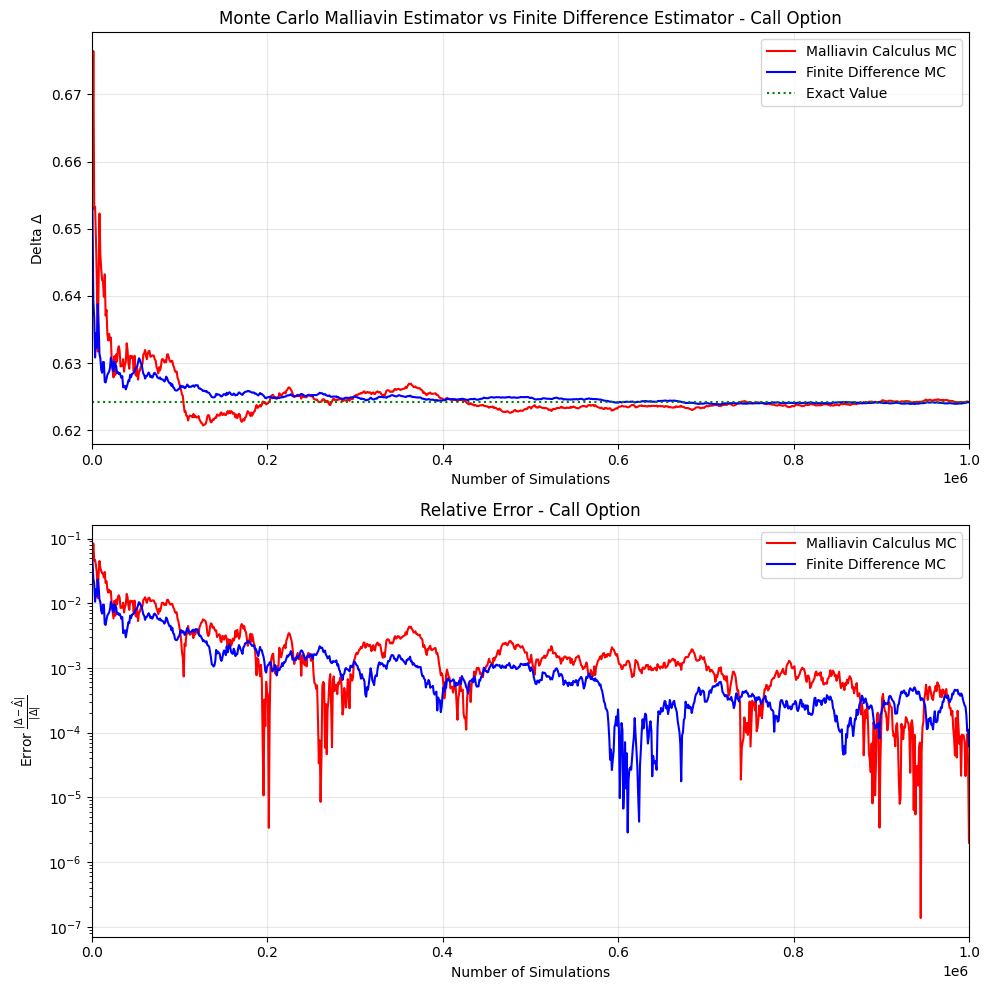

In [23]:
sizes, fd_deltas = delta_fd(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_deltas = delta_malliavin(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N)
call_delta = call_delta_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Delta for European Call':<54} = {call_delta:10.8f}")
print(f"{'Delta for European Call by Finite Differences Estimator':<54} = {fd_deltas[-1]:10.8f}")
print(f"{'Delta for European Call by MC Malliavin Estimator':<54} = {malliavin_deltas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_deltas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_deltas, color="blue", label="Finite Difference MC")
ax[0].hlines(call_delta, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Delta $\Delta$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Call Option")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_deltas - call_delta) / np.abs(call_delta), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_deltas - call_delta) / np.abs(call_delta), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $\frac{|\Delta - \hat{\Delta}|}{|\Delta|}$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Relative Error - Call Option")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

For a European Call option with a continuous and piecewise smooth payoff, both the Finite Difference estimator and the Malliavin Monte Carlo estimator converge smoothly to the analytical Black-Scholes benchmark $\approx 0.62425$. The relative error for both estimators drops below $10^{-4}$. Since the payoff function $F(x) = \max(x-K, 0)$ is Lipschitz continuous, the finite difference method performs remarkably well and exhibits a variance profile comparable to that of the Malliavin approach.

## Digital Call Option

### Analytical Delta

Under the Black-Scholes model, the exact value of the Delta of a digital call option is
$$
\Delta = \frac{e^{-rT}\phi(d_2)}{x\sigma\sqrt{T}},
$$
where $\phi$ is the probability density function (PDF) of the standard normal distribution and
$$
d_2=\frac{\log \left( \frac{x}{K} \right) + \left( r - \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [26]:
def digital_call_delta_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d2 = np.log(x / KrT) / s - s / 2
        delta = np.exp(-r*T)*stats.norm.pdf(d2) / (x * s)
     
    return delta

### Numerical Results and Comparison

Delta for Digital Call                                = 0.01264776
Delta for Digital Call by Finite Differences Estimator = 0.01253245
Delta for Digital Call by MC Malliavin Estimator      = 0.01263951


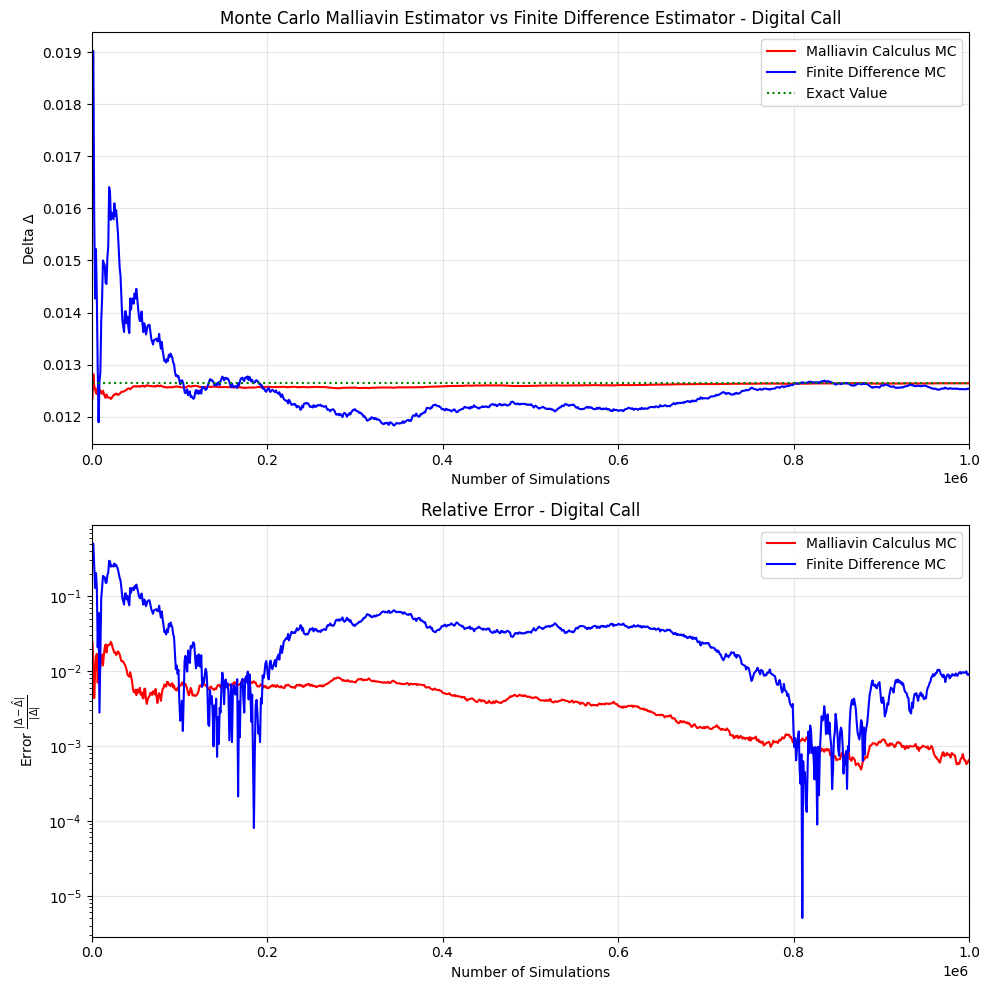

In [28]:
sizes, fd_deltas = delta_fd(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_deltas = delta_malliavin(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N)
digital_call_delta = digital_call_delta_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Delta for Digital Call':<53} = {digital_call_delta:10.8f}")
print(f"{'Delta for Digital Call by Finite Differences Estimator':<53} = {fd_deltas[-1]:10.8f}")
print(f"{'Delta for Digital Call by MC Malliavin Estimator':<53} = {malliavin_deltas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_deltas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_deltas, color="blue", label="Finite Difference MC")
ax[0].hlines(digital_call_delta, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Delta $\Delta$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Digital Call")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_deltas - digital_call_delta) / np.abs(digital_call_delta), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_deltas - digital_call_delta) / np.abs(digital_call_delta), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $\frac{|\Delta - \hat{\Delta}|}{|\Delta|}$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Relative Error - Digital Call")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The superior performance of the Malliavin calculus approach becomes evident when evaluating non-smooth or discontinuous payoffs, such as a Digital Call option $\mathbb{1}_{\{S_T > K\}}$. The finite difference estimator suffers from high variance caused by the localized step-discontinuity at strike $K$, requiring a bump parameter $\varepsilon$ that inherently introduces a trade-off between truncation bias and numerical instability. Conversely, by shifting the derivative operator from the payoff to the underlying Malliavin weight, the Malliavin estimator bypasses the distribution-valued derivative (Dirac delta). The plots demonstrate that Malliavin Monte Carlo converges rapidly to the exact value $\approx 0.01265$ with a relative error stabilized around $10^{-3}$, whereas FD exhibits persistent oscillations and a significantly higher relative error $\approx 10^{-2}$.   

## Arithmetic Asian Options

For arithmetic Asian options, no elementary closed-form formula exists for Delta. The sum of log-normal random variables does not yield a distribution known in closed form, rendering elementary analytical integration impossible. So we exploit the Malliavin calculus technique to compute it.

We know that in general is not allowed to "take out" a random variable from an Itô integral: let us see how this can be made in the case of the anticipative stochastic integral.

**Proposition**

Let $X\in\mathbb{D}^{1,2}$ and let $U$ be a second-order Skorohod-integrable process. Then
$$
\int_0^T XU_t\diamond\,dW_t = X\int_0^T U_t\diamond\,dW_t - \int_0^T\left(D_t X\right)u_t\,dt.
$$

**Proof**

For every $Y\in\mathcal{S}$, we have
\begin{align*}
\mathbb{E}\left[YD^*(XU)\right] &\underbrace{=}_{\text{(by the duality relation)}} \mathbb{E}\left[\int_0^T(D_t Y)X U_t\,dt\right] \\
&\underbrace{=}_{\text{(by the chain rule)}} \mathbb{E}\left[\int_0^T \left(D_t(YX)-YD_t X\right)U_t\,dt\right] \\
&\underbrace{=}_{\text{(by the duality relation)}} \mathbb{E}\left[Y\left(XD^* U - \int_0^T D_t XU_t\,dt\right)\right], \\
\end{align*}
and the claim follows by density.
<div style="text-align: right;">$\square\qquad\qquad$</div>

This formula is crucial for the the computation of Skorohod integrals. The typical case is when $U$ is adapted, in this case the formula becomes
$$
\int_0^T XU_t\diamond\, dW_t = X\int_0^T U_t\,dW_t - \int_0^T (D_t X)U_t\,dt,
$$
and so, it is possible to express the Skorohod integral as the sum of an Itô integral and of a Lebesgue integral.

### Malliavin Delta for Asian Options

We give the expression of the Delta of an arithmetic Asian option with Black-Scholes dynamics for the underlying asset. We denote the average by
$$
X=\frac{1}{T}\int_0^T S_t\,dt,
$$
and we observe that $\partial_x X=\frac{X}{x}=\frac{1}{Tx}\int_0^T S_t\,dt$ and
$$
\int_0^T D_s X\,ds=\frac{1}{T}\int_0^T\int_0^T D_s S_t\,dt\,ds=\frac{\sigma}{T}\int_0^T\int_0^t S_t\,ds\,dt=\frac{\sigma}{T}\int_0^T t S_t\,dt.
$$
Then we have
\begin{align*}
\Delta &= e^{-rT}\partial_x\mathbb{E}\left[F(X)\right] \\
&= e^{-rT}\mathbb{E}\left[F'(X)\partial_x X\right] \\
&= e^{-rT}\mathbb{E}\left[F(X)\int_0^T\frac{\partial_x X}{\int_0^T D_s X\,ds}\diamond\,dW_t\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\int_0^T\frac{\int_0^T S_s\,ds}{\int_0^T s S_s\,ds}\diamond\,dW_t\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\int_0^T D_t\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\right)\,dt\right)\right],
\end{align*}
where in the last equality we applied the proposition with $X=\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}$ and $U=1$. Using the fact that the Malliavin derivative follows regular derivation rules, we have
\begin{align*}
\Delta &= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\int_0^T \frac{\int_0^T D_t S_s\,ds\cdot\int_0^T sS_s\,ds - \int_0^T S_s\,ds\cdot\int_0^T s D_t S_s\,ds}{\left(\int_0^T sS_s\,ds\right)^2}\,dt\right)\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\frac{\int_0^T\int_t^T D_t S_s\,ds\,dt\cdot\int_0^T sS_s\,ds - \int_0^T S_s\,ds\cdot\int_0^T\int_t^T s D_t S_s\,ds\,dt}{\left(\int_0^T sS_s\,ds\right)^2}\right)\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\frac{\int_0^T\left(\int_0^s \,dt\right)\sigma S_s\,ds\cdot\int_0^T sS_s\,ds - \int_0^T S_s\,ds\cdot\int_0^T\left(\int_0^s\,dt\right)s \sigma S_s\,ds}{\left(\int_0^T sS_s\,ds\right)^2}\right)\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\sigma\frac{\int_0^T s S_s\,ds\cdot\int_0^T s S_s\,ds - \int_0^T S_s\,ds\cdot\int_0^T s^2 S_s\,ds}{\left(\int_0^T sS_s\,ds\right)^2}\right)\right] \\
&= \frac{e^{-rT}}{\sigma x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\cdot W_T-\sigma+\sigma\frac{\int_0^T S_s\,ds\cdot\int_0^T s^2 S_s\,ds}{\left(\int_0^T sS_s\,ds\right)^2}\right)\right] \\
&= \frac{e^{-rT}}{x}\mathbb{E}\left[F(X)\left(\frac{\int_0^T S_s\,ds}{\int_0^T sS_s\,ds}\left(\frac{W_T}{\sigma}+\frac{\int_0^T s^2 S_s\,ds}{\int_0^T sS_s\,ds}\right)-1\right)\right].
\end{align*}

In [31]:
def delta_malliavin_asian(payoff, r, sigma, x, T, N, M):

    # Time discretization
    dt = T / M
    t = np.linspace(0, T , M + 1)

    # Simulation of Brownian motion paths, generate dW with shape (N, M) and construct W with shape (N, M+1)
    dW = np.random.normal(scale=np.sqrt(dt), size=(N, M))
    W = np.concatenate([np.zeros((N, 1)), np.cumsum(dW, axis=1)], axis=1)

    # Simulation of Geometric Brownian Motion paths, S will have shape (N, M+1)
    S = x * np.exp((r - 0.5 * sigma**2) * t + sigma * W)

    # Computation of integrals using the trapezoidal rule along the time axis
    I_0 = np.trapz(S, t, axis=1)                 # Integral of S_s
    I_1 = np.trapz(S * t, t, axis=1)             # Integral of s * S_s
    I_2 = np.trapz(S * t**2, t, axis=1)          # Integral of s^2 * S_s

    # Terminal value of Brownian motion W_T
    W_T = W[:, -1]

    # Computation of the Malliavin weight
    malliavin_weight = (I_0 / I_1) * ((W_T / sigma) + (I_2 / I_1)) - 1

    payoffs = payoff(I_0 / T)
    constant = np.exp(-r * T) / x

    # Monte Carlo estimator
    deltas = []
    sizes = range(1000, N+1, 1000)
    for k in sizes:
        mc_estimator = np.mean(payoffs[:k] * malliavin_weight[:k])
        delta = constant * mc_estimator
        deltas.append(delta)

    return sizes, deltas

### Finite difference Delta for Asian Options

In [33]:
def delta_fd_asian(payoff, r, sigma, x, T, N, epsilon, M):

    # Time discretization
    dt = T / M
    times = np.linspace(0, T, M + 1)
    
    # Simulation of Brownian motion paths, generate dW with shape (N, M) and construct W with shape (N, M+1)
    dW = np.random.normal(scale=np.sqrt(dt), size=(N, M))
    W = np.concatenate([np.zeros((N, 1)), np.cumsum(dW, axis=1)], axis=1)
    
    # Simultaneous simulation of bumped underlying paths (up and down)
    gbm_sample_up = (x + epsilon) * np.exp((r - 0.5 * sigma**2) * times + sigma * W)
    gbm_sample_down = (x - epsilon) * np.exp((r - 0.5 * sigma**2) * times + sigma * W)
    
    # Computation of the time-average across the entire trajectory
    X_up = np.trapz(gbm_sample_up, times, axis=1) / T
    X_down = np.trapz(gbm_sample_down, times, axis=1) / T
    
    # Vectorized payoff evaluation across all N paths
    pvps = payoff(X_up)
    pvms = payoff(X_down)
    
    constant = np.exp(-r * T)
    
    # Monte Carlo estimator
    deltas = []
    sizes = range(1000, N+1, 1000)
    
    for k in sizes:
        mc_estimator = (np.mean(pvps[:k]) - np.mean(pvms[:k])) / (2.0 * epsilon)
        deltas.append(constant * mc_estimator)
            
    return sizes, deltas

### Numerical Results and Comparison

To calculate the time-average of the trajectory in the Asian option, we discretize the interval $[0,T]$ into $M$ subintervals. We choose

In [35]:
M = 100

Delta for Asian Option by Finite Differences Estimator = 0.57083164
Delta for Asian Option by MC Malliavin Estimator      = 0.56954358


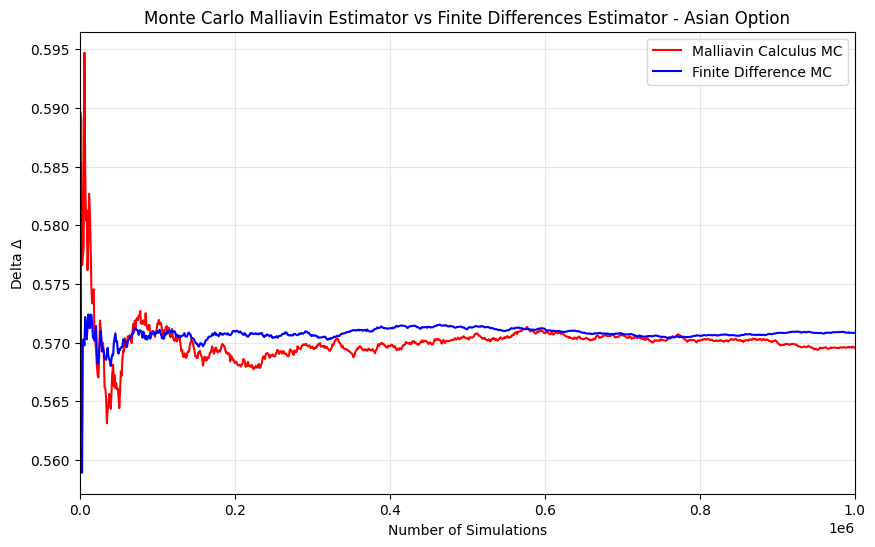

In [36]:
sizes, fd_deltas = delta_fd_asian(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon, M=M)
sizes, malliavin_deltas = delta_malliavin_asian(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, M=M)

print(f"{'Delta for Asian Option by Finite Differences Estimator':<53} = {fd_deltas[-1]:10.8f}")
print(f"{'Delta for Asian Option by MC Malliavin Estimator':<53} = {malliavin_deltas[-1]:10.8f}")

plt.figure(figsize=(10, 6))
plt.plot(sizes, malliavin_deltas, color="red", label="Malliavin Calculus MC")
plt.plot(sizes, fd_deltas, color="blue", label="Finite Difference MC")
plt.xlim([0.0, sizes[-1]])
plt.ylabel(r"Delta $\Delta$")
plt.xlabel("Number of Simulations")
plt.title("Monte Carlo Malliavin Estimator vs Finite Differences Estimator - Asian Option")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Since no analytical closed-form formula exists for the arithmetic Asian option due to the log-normal sum distribution problem, numerical simulation is indispensable. The comparison between Finite Differences and Malliavin Monte Carlo shows asymptotic agreement towards a Delta value of approximately $0.5702$. While the Malliavin weight requires pathwise numerical integration via the trapezoidal rule over $M=100$ time steps, it evaluates the sensitivity without re-simulating bumped trajectories. This eliminates the finite-difference step-size parameter $\varepsilon$ and avoids additional spatial truncation error.  

# Vega computation

### Finite difference Vega

The finite difference method (central difference scheme) for the Vega has the form
$$
\mathcal{V} \approx e^{-rT}\frac{\mathbb{E}\left[F(S_T)|\sigma=\sigma+\varepsilon\right]-\mathbb{E}\left[F(S_T)|\sigma=\sigma-\varepsilon\right]}{2\varepsilon},
$$
with sufficiently small $\varepsilon$.

In [39]:
def vega_fd(payoff, r, sigma, x, T, N, epsilon):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample_up= x*np.exp((r - 0.5*(sigma+epsilon)**2)*T + (sigma+epsilon)*W_T)
    gbm_sample_down = x*np.exp((r - 0.5*(sigma-epsilon)**2)*T + (sigma-epsilon)*W_T)
    constant = np.exp(-r*T)
    
    payoff_plus = payoff(gbm_sample_up)
    payoff_minus = payoff(gbm_sample_down)
    
    vegas = []
    sizes = range(1000, N+1, 1000)
    
    for k in sizes:
        
        fd = np.mean((payoff_plus[:k] - payoff_minus[:k])/(2.0*epsilon))
        vega = constant*fd
        vegas.append(vega)
        
    return sizes, vegas

### Malliavin Vega

We first notice that $D_s S_T=\sigma S_T$ and $\partial_\sigma S_T=(W_T - \sigma T)S_T$. Then, we have the following expression for the Vega in the Black-Scholes model
\begin{align*}
\mathcal{V} &= e^{-rT}\partial_\sigma\mathbb{E}[F(S_T)] \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\int_0^T \frac{W_T-\sigma T}{\sigma T}\diamond\,dW_t\right] \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\left(\frac{W_T-\sigma T}{\sigma T} W_T - \int_0^T \frac{1}{\sigma T}\,dt\right)\right] \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\left(\frac{W_T^2-\sigma T W_T}{\sigma T} - \frac{1}{\sigma}\right)\right] \\
&= \frac{e^{-rT}}{\sigma T}\mathbb{E}\left[F(S_T)\left(W_T^2-\sigma T W_T - T\right)\right],
\end{align*}
where we applied the proposition with $X=\frac{W_T-\sigma T}{\sigma T}$ and $U=1$. 

In [41]:
def vega_malliavin(payoff, r, sigma, x, T, N):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample = x*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    constant = np.exp(-r*T) / (sigma*T)

    vegas = []
    sizes = range(1000, N+1, 1000)
    for k in sizes:
        
        mc_estimator = np.mean(payoff(gbm_sample[:k])*(W_T[:k]**2 - sigma*T*W_T[:k] - T))
        vega = constant*mc_estimator
        vegas.append(vega)
    
    return sizes, vegas

## European Call Option

### Analytical Delta

Under the Black-Scholes model, the exact value of the Vega of a call option is
$$
\mathcal{V} = x\sqrt{T}\phi(d_1),
$$
where $\phi$ is the probability density function (PDF) of the standard normal distribution and
$$
d_1=\frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [43]:
def call_vega_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        vega = x*np.sqrt(T)*stats.norm.pdf(d1)
     
    return vega

### Numerical Results and Comparison

Vega for European Call                                 = 37.94329331
Vega for European Call by Finite Differences Estimator = 37.81981034
Vega for European Call by MC Malliavin Estimator       = 38.07402700


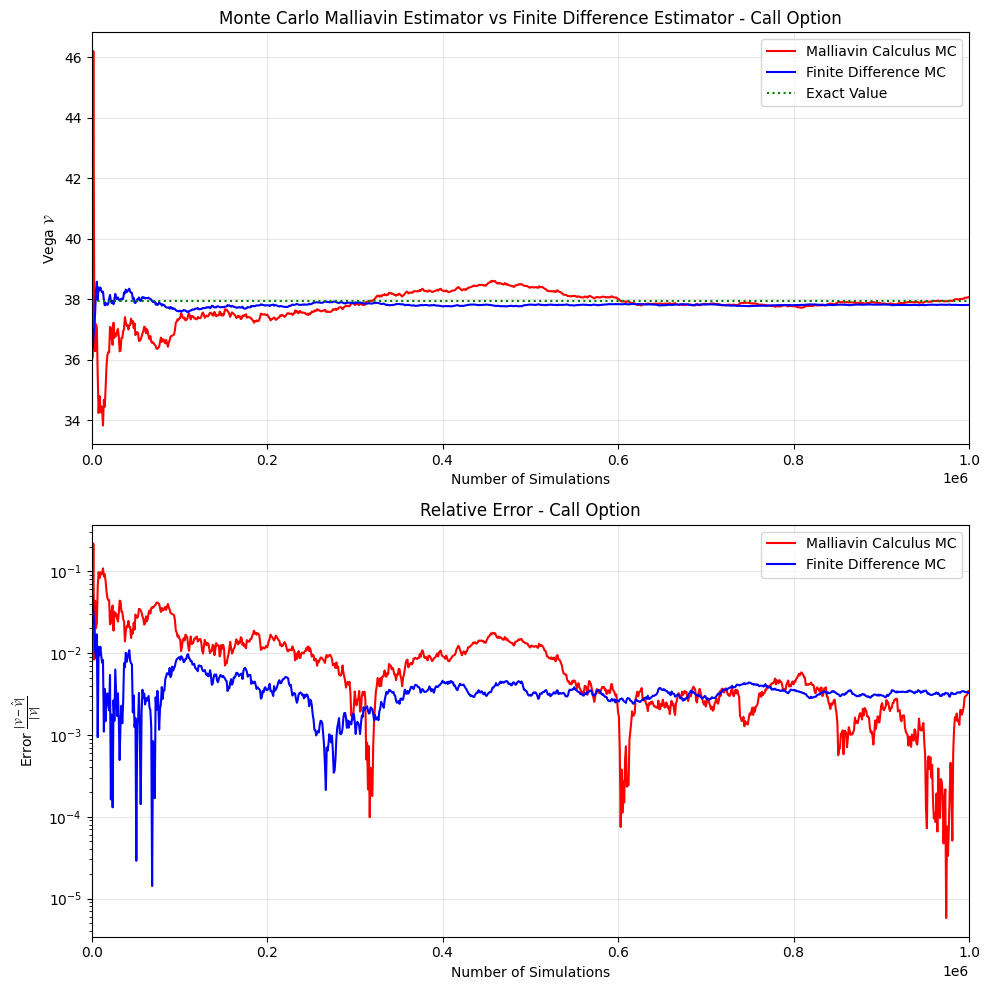

In [104]:
sizes, fd_vegas = vega_fd(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_vegas = vega_malliavin(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N)
call_vega = call_vega_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Vega for European Call':<54} = {call_vega:10.8f}")
print(f"{'Vega for European Call by Finite Differences Estimator':<54} = {fd_vegas[-1]:10.8f}")
print(f"{'Vega for European Call by MC Malliavin Estimator':<54} = {malliavin_vegas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_vegas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_vegas, color="blue", label="Finite Difference MC")
ax[0].hlines(call_vega, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Vega $\mathcal{V}$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Call Option")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_vegas - call_vega) / np.abs(call_vega), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_vegas - call_vega) / np.abs(call_vega), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $\frac{|\mathcal{V} - \hat{\mathcal{V}}|}{|\mathcal{V}|}$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Relative Error - Call Option")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Both estimators successfully converge to the analytical exact Vega $\approx 37.943$. For small sample sizes $N < 200,000$, the Malliavin Vega estimator displays slightly higher sample variance than Finite Differences due to the presence of quadratic Brownian terms $W_T^2$ in its stochastic weight. However, as $N$ approaches $1,000,000$, the relative error of the Malliavin estimator decreases steadily below $10^{-2}$, achieving high stability and matching the precision of the finite-difference scheme.

## Digital Call Option

### Analytical Vega

Under the Black-Scholes model, the exact value of the Vega of a digital call option is
$$
\mathcal{V} = - e^{-r T}\phi(d_2)\frac{d_1}{\sigma}
$$
where $\phi$ is the probability density function (PDF) of the standard normal distribution and
\begin{align*}
d_1 &= \frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}, \\
d_2 &= \frac{\log \left( \frac{x}{K} \right) + \left( r - \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
\end{align*}

In [48]:
def digital_call_vega_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        d2 = d1 - s
        vega = - np.exp(-r * T) * stats.norm.pdf(d2) * d1 / sigma
     
    return vega

### Numerical Results and Comparison

Vega for Digital Call                                 = -0.40051254
Vega for Digital Call by Finite Differences Estimator = -0.42516626
Vega for Digital Call by MC Malliavin Estimator       = -0.39884694


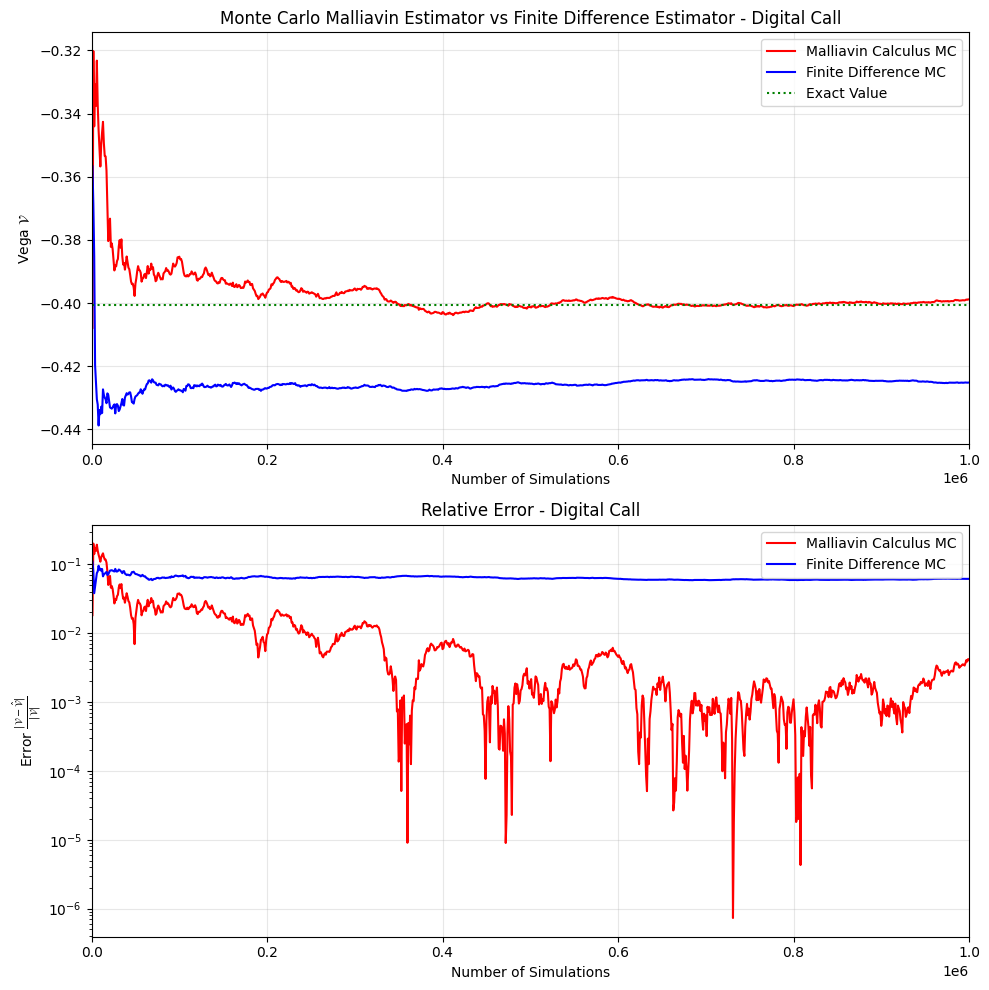

In [108]:
sizes, fd_vegas = vega_fd(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_vegas = vega_malliavin(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N)
digital_call_vega = digital_call_vega_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Vega for Digital Call':<53} = {digital_call_vega:10.8f}")
print(f"{'Vega for Digital Call by Finite Differences Estimator':<53} = {fd_vegas[-1]:10.8f}")
print(f"{'Vega for Digital Call by MC Malliavin Estimator':<53} = {malliavin_vegas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_vegas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_vegas, color="blue", label="Finite Difference MC")
ax[0].hlines(digital_call_vega, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Vega $\mathcal{V}$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Digital Call")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_vegas - digital_call_vega) / np.abs(digital_call_vega), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_vegas - digital_call_vega) / np.abs(digital_call_vega), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $\frac{|\mathcal{V} - \hat{\mathcal{V}}|}{|\mathcal{V}|}$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Relative Error - Digital Call")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The computation of Vega for a Digital Call option provides another compelling case for Malliavin Calculus. The finite difference estimator exhibits a persistent systemic bias and poor convergence, keeping its relative error bounded above $5\%$ even at $1,000,000$ trajectories. In contrast, the Malliavin estimator correctly handles the discontinuous sensitivity, converging efficiently to the exact value $\approx -0.4005$ with a relative error reduction of more than one order of magnitude.

## Arithmetic Asian Options

For arithmetic Asia options, no elementary closed-form formula exists for Vega. 

### Malliavin Vega for Asian Options

We give the expression of the Vega of an arithmetic Asian option with Black-Scholes dynamics for the underlying asset. We denote the average by
$$
X=\frac{1}{T}\int_0^T S_t\,dt,
$$
and, as already calculated, we have

$$
D_s S_T=\sigma S_T,\quad\partial_\sigma S_T=(W_T - \sigma T)S_T,\quad\int_0^T D_s X\,ds=\frac{\sigma}{T}\int_0^T t S_t\,dt.
$$

Then

\begin{align*}
\partial_\sigma X &= \frac{1}{T}\int_0^T \partial_\sigma S_t\,dt \\
&= \frac{1}{T}\int_0^T W_t S_t\,dt - \frac{\sigma}{T}\int_0^T t S_t\,dt.
\end{align*}

Putting all together, we have

\begin{align*}
\mathcal{V} &= e^{-rT}\partial_\sigma\mathbb{E}\left[F(X)\right] \\
&= e^{-rT}\mathbb{E}\left[F'(X)\partial_\sigma X\right] \\
&= e^{-rT}\mathbb{E}\left[F(X)\int_0^T\frac{\partial_\sigma X}{\int_0^T D_s X\,ds}\diamond\,dW_t\right] \\
&= e^{-rT}\mathbb{E}\left[F(X)\int_0^T\left(\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}-1\right)\diamond\,dW_t\right] \\
&= e^{-rT}\mathbb{E}\left[F(X)\left(\left(\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}-1\right)W_T - \int_0^T D_t\left(\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}\right)\,dt\right)\right] \\
\end{align*}

where in the last equality we applied the proposition with $X=\displaystyle\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}-1$ and $U=1$. Using the fact that the Malliavin derivative follows regular derivation rules, we have

\begin{align*}
\int_0^T D_t\left(\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}\right)\,dt &= \frac{1}{\sigma}\int_0^T\frac{\int_0^T D_t (W_s S_s)\,ds\cdot\int_0^T s S_s\,ds - \int_0^T W_s S_s\,ds\cdot\int_0^T s D_t S_s\, ds}{\left(\int_0^T s S_s\,ds\right)^2}\,dt \\
&= \frac{1}{\sigma}\frac{\int_0^T\int_0^T \left(D_t W_s S_s + W_s D_t S_s\right)\,ds\,dt\cdot\int_0^T s S_s\,ds - \int_0^T W_s S_s\,ds\cdot\int_0^T\int_0^T s D_t S_s\, ds\,dt}{\left(\int_0^T s S_s\,ds\right)^2} \\
&= \frac{1}{\sigma}\frac{\int_0^T\int_0^s \left(S_s + W_s \sigma S_s\right)\,dt\,ds\cdot\int_0^T s S_s\,ds - \int_0^T W_s S_s\,ds\cdot\int_0^T\int_0^s s \sigma S_s\,dt\,ds}{\left(\int_0^T s S_s\,ds\right)^2} \\
&= \frac{1}{\sigma}\frac{\int_0^T\left(s S_s + \sigma s W_s S_s\right)\,ds\cdot\int_0^T s S_s\,ds - \int_0^T W_s S_s\,ds\cdot\int_0^T \sigma s^2 S_s\,ds}{\left(\int_0^T s S_s\,ds\right)^2} \\
&= \frac{1}{\sigma} + \frac{\int_0^T s W_s S_s\,ds}{\int_0^T s S_s\,ds} - \frac{\int_0^T W_s S_s\,ds\cdot\int_0^T s^2 S_s\,ds}{\left(\int_0^T s S_s\,ds\right)^2}.
\end{align*}

In conclusion
$$
\mathcal{V} = e^{-rT}\mathbb{E}\left[F(X)\left(\left(\frac{\int_0^T W_s S_s\,ds}{\sigma\int_0^T s S_s\,ds}-1\right)W_T - \frac{1}{\sigma} - \frac{\int_0^T s W_s S_s\,ds}{\int_0^T s S_s\,ds} + \frac{\int_0^T W_s S_s\,ds\cdot\int_0^T s^2 S_s\,ds}{\left(\int_0^T s S_s\,ds\right)^2}\right)\right].
$$

In [53]:
def vega_malliavin_asian(payoff, r, sigma, x, T, N, M):

    # Time discretization
    dt = T / M
    t = np.linspace(0, T , M + 1)

    # Simulation of Brownian motion paths, generate dW with shape (N, M) and construct W with shape (N, M+1)
    dW = np.random.normal(scale=np.sqrt(dt), size=(N, M))
    W = np.concatenate([np.zeros((N, 1)), np.cumsum(dW, axis=1)], axis=1)

    # Simulation of Geometric Brownian Motion paths, S will have shape (N, M+1)
    S = x * np.exp((r - 0.5 * sigma**2) * t + sigma * W)

    # Computation of integrals using the trapezoidal rule along the time axis
    I_0 = np.trapz(S, t, axis=1)                 # Integral of S_s
    I_1 = np.trapz(S * t, t, axis=1)             # Integral of s * S_s
    I_2 = np.trapz(S * t**2, t, axis=1)          # Integral of s^2 * S_s
    I_0_W = np.trapz(S * W, t, axis=1)           # Integral of W_s * S_s
    I_1_W = np.trapz(S * W * t, t, axis=1)       # Integral of s * W_s * S_s

    # Terminal value of Brownian motion W_T
    W_T = W[:, -1]

    # Computation of the Malliavin weight
    malliavin_weight = (I_0_W / (sigma * I_1) - 1.0) * W_T - 1.0 / sigma - I_1_W / I_1 + (I_0_W * I_2) / (I_1)**2

    payoffs = payoff(I_0 / T)
    constant = np.exp(-r * T)

    # Monte Carlo estimator
    vegas = []
    sizes = range(1000, N+1, 1000)
    for k in sizes:
        mc_estimator = np.mean(payoffs[:k] * malliavin_weight[:k])
        vega = constant * mc_estimator
        vegas.append(vega)

    return sizes, vegas

### Finite difference Vega for Asian Options

In [55]:
def vega_fd_asian(payoff, r, sigma, x, T, N, epsilon, M):

    # Time discretization
    dt = T / M
    times = np.linspace(0, T, M + 1)
    
    # Simulation of Brownian motion paths, generate dW with shape (N, M) and construct W with shape (N, M+1)
    dW = np.random.normal(scale=np.sqrt(dt), size=(N, M))
    W = np.concatenate([np.zeros((N, 1)), np.cumsum(dW, axis=1)], axis=1)
    
    # Simultaneous simulation of bumped underlying paths (up and down)
    gbm_sample_up = x * np.exp((r - 0.5 * (sigma + epsilon)**2) * times + (sigma + epsilon) * W)
    gbm_sample_down = x * np.exp((r - 0.5 * (sigma - epsilon)**2) * times + (sigma - epsilon) * W)
    
    # Computation of the time-average across the entire trajectory
    X_up = np.trapz(gbm_sample_up, times, axis=1) / T
    X_down = np.trapz(gbm_sample_down, times, axis=1) / T
    
    # Vectorized payoff evaluation across all N paths
    pvps = payoff(X_up)
    pvms = payoff(X_down)
    
    constant = np.exp(-r * T)
    
    # Monte Carlo estimator
    vegas = []
    sizes = range(1000, N+1, 1000)
    
    for k in sizes:
        mc_estimator = (np.mean(pvps[:k]) - np.mean(pvms[:k])) / (2.0 * epsilon)
        vegas.append(constant * mc_estimator)
            
    return sizes, vegas

### Numerical Results and Comparison

Vega for Asian Option by Finite Differences Estimator = 21.84091342
Vega for Asian Option by MC Malliavin Estimator       = 21.78499412


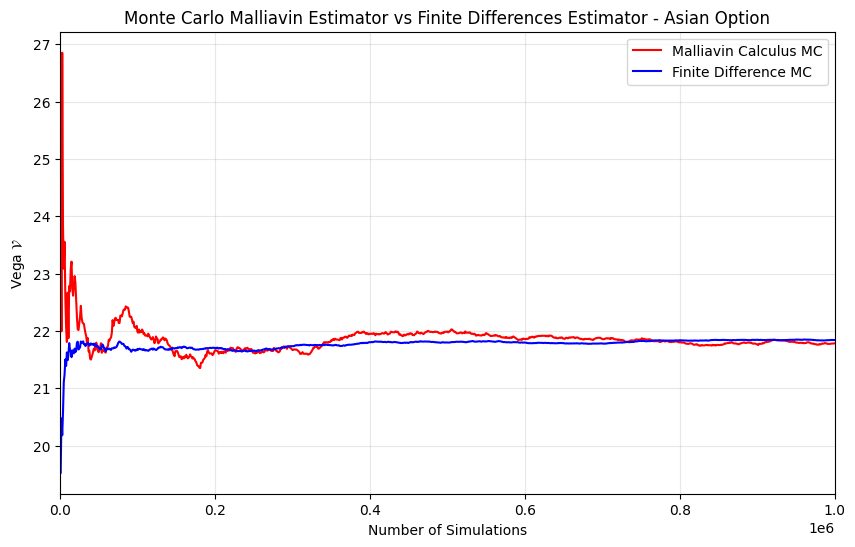

In [57]:
sizes, fd_vegas = vega_fd_asian(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon, M=M)
sizes, malliavin_vegas = vega_malliavin_asian(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, M=M)

print(f"{'Vega for Asian Option by Finite Differences Estimator':<53} = {fd_vegas[-1]:10.8f}")
print(f"{'Vega for Asian Option by MC Malliavin Estimator':<53} = {malliavin_vegas[-1]:10.8f}")

plt.figure(figsize=(10, 6))
plt.plot(sizes, malliavin_vegas, color="red", label="Malliavin Calculus MC")
plt.plot(sizes, fd_vegas, color="blue", label="Finite Difference MC")
plt.xlim([0.0, sizes[-1]])
plt.ylabel(r"Vega $\mathcal{V}$")
plt.xlabel("Number of Simulations")
plt.title("Monte Carlo Malliavin Estimator vs Finite Differences Estimator - Asian Option")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In the absence of closed-form solutions, the Malliavin Vega estimator for the arithmetic Asian option converges reliably towards $\approx 21.785$, closely tracking the Finite Difference baseline $\approx 21.841$. The Malliavin formulation extracts Vega from a single Monte Carlo run by applying Skorohod integration over the pathwise integrals, offering a unbiased gradient estimate.

# Gamma computation

### Finite difference Gamma

The finite difference method (central difference scheme) for the Gamma has the form
$$
\Gamma \approx e^{-rT}\frac{\mathbb{E}\left[F(S_T)|S_0=x+\varepsilon\right]-2\mathbb{E}\left[F(S_T)|S_0=x\right]+\mathbb{E}\left[F(S_T)|S_0=x-\varepsilon\right]}{\varepsilon^2},
$$
with sufficiently small $\varepsilon$.

In [60]:
def gamma_fd(payoff, r, sigma, x, T, N, epsilon):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample = x*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    gbm_sample_up = (x + epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    gbm_sample_down = (x - epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    constant = np.exp(-r*T)

    payoff_ = payoff(gbm_sample)
    payoff_plus = payoff(gbm_sample_up)
    payoff_minus = payoff(gbm_sample_down)
    
    gammas = []
    sizes = range(1000, N+1, 1000)
    
    for k in sizes:
        
        fd = np.mean((payoff_plus[:k] - 2*payoff_[:k] + payoff_minus[:k])/(epsilon**2))
        gamma = constant*fd
        gammas.append(gamma)
        
    return sizes, gammas

### Malliavin Gamma

From previous calculations, we have
$$
\Delta = e^{-rT}\partial_x\mathbb{E}\left[F(S_T)\right] = \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F(S_T)W_T\right].
$$
Since $D_s S_T=\sigma S_T$ and $\partial_x S_T=\frac{S_T}{x}$, the Gamma of an option with payoff function $F$ in the Black-Scholes model is
\begin{align*}
\Gamma &= e^{-rT}\partial_{xx}\mathbb{E}[F(S_T)] \\
&= \frac{e^{-rT}}{\sigma T}\mathbb{E}\left[\partial_x\left(\frac{F(S_T)}{x}\right) W_T\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[\partial_x F(S_T) W_T\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F'(S_T)\partial_x S_T W_T\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F'(S_T)\frac{S_T W_T}{x}\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F(S_T) \int_0^T \frac{W_T}{\sigma T x}\diamond\,dW_t\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F(S_T) \left( \frac{W_T}{\sigma T x}W_T - \int_0^T \frac{1}{\sigma T x}\,dt\right)\right] \\
&= -\frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T)W_T\right] + \frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T) \left( \frac{W_T^2 - T}{\sigma T}\right)\right] \\
&= \frac{e^{-rT}}{\sigma T x^2}\mathbb{E}\left[F(S_T) \left( \frac{W_T^2 - T}{\sigma T} - W_T\right)\right] \\
&= \frac{e^{-rT}}{\sigma^2 T^2 x^2}\mathbb{E}\left[F(S_T) \left(W_T^2 - \sigma T W_T - T\right)\right],
\end{align*}
where we applied the stochastic integration by parts theorem with $u=1$ and $Y=\frac{S_T W_T}{x}$ and the proposition with $U=1$ and $X=\frac{W_T}{\sigma T x}$.

As expected, the obtained formulas for $\Gamma$ and $\mathcal{V}$ satisfy the *gamma-vega relationship*
$$
\Gamma = \frac{1}{\sigma T x^2}\mathcal{V}.
$$

In [62]:
def gamma_malliavin(payoff, r, sigma, x, T, N):

    W_T = np.random.normal(scale=np.sqrt(T), size=N)
    gbm_sample = x*np.exp((r - 0.5*sigma**2)*T + sigma*W_T)
    constant = np.exp(-r*T) / ((sigma*T*x)**2)

    gammas = []
    sizes = range(1000, N+1, 1000)
    for k in sizes:
        
        mc_estimator = np.mean(payoff(gbm_sample[:k])*(W_T[:k]**2 - sigma*T*W_T[:k] - T))
        gamma = constant*mc_estimator
        gammas.append(gamma)
    
    return sizes, gammas

## European Call Option

### Analytical Gamma

Under the Black-Scholes model, the exact value of the Gamma of a call option is
$$
\Gamma = \frac{\phi(d_1)}{\sigma x \sqrt{T}},
$$
where $\phi$ is the probability density function (PDF) of the standard normal distribution and
$$
d_1=\frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [64]:
def call_gamma_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        gamma = stats.norm.pdf(d1) / (s * x)
     
    return gamma

### Numerical Results and Comparison

Gamma for European Call                                = 0.01264776
Gamma for European Call by Finite Differences Estimator = 0.01252580
Gamma for European Call by MC Malliavin Estimator      = 0.01253318


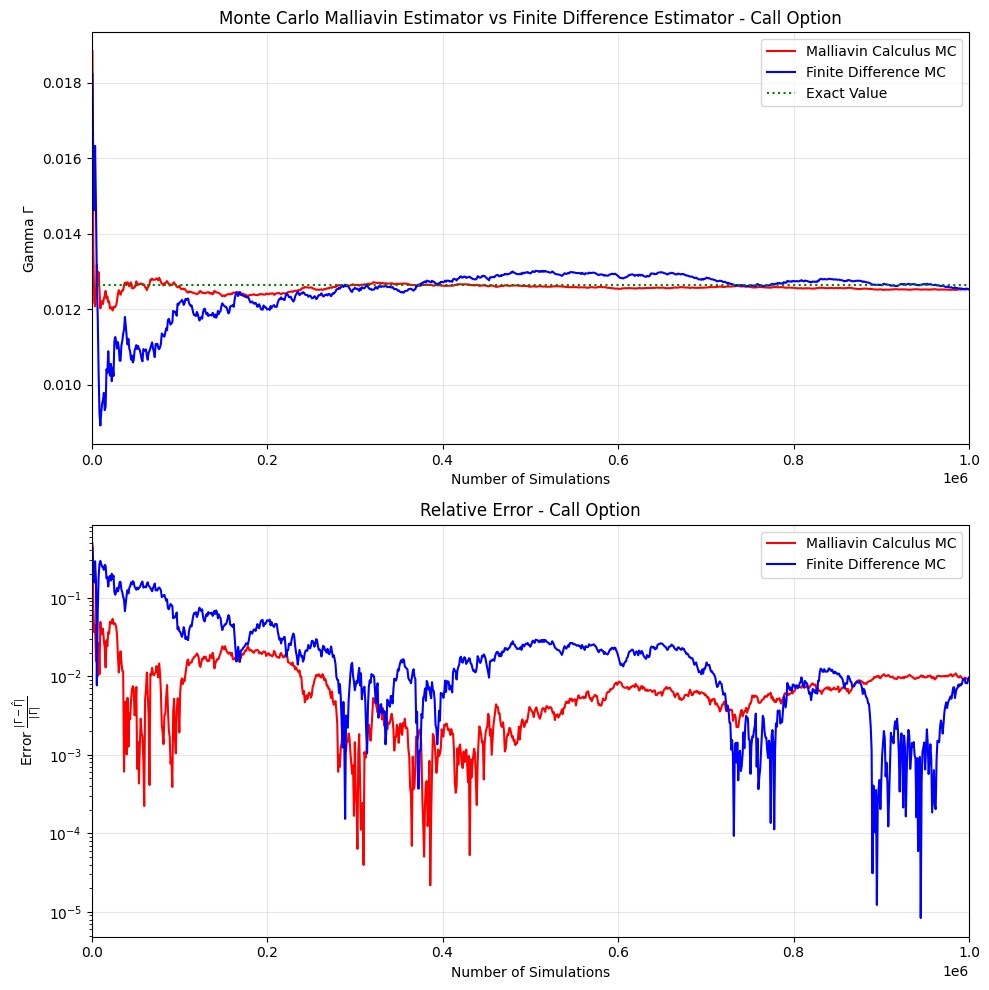

In [66]:
sizes, fd_gammas = gamma_fd(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_gammas = gamma_malliavin(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N)
call_gamma = call_gamma_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Gamma for European Call':<54} = {call_gamma:10.8f}")
print(f"{'Gamma for European Call by Finite Differences Estimator':<54} = {fd_gammas[-1]:10.8f}")
print(f"{'Gamma for European Call by MC Malliavin Estimator':<54} = {malliavin_gammas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_gammas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_gammas, color="blue", label="Finite Difference MC")
ax[0].hlines(call_gamma, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Gamma $\Gamma$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Call Option")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_gammas - call_gamma) / np.abs(call_gamma), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_gammas - call_gamma) / np.abs(call_gamma), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $\frac{|\Gamma - \hat{\Gamma}|}{|\Gamma|}$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Relative Error - Call Option")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Estimating second-order Greeks (Gamma) via Finite Differences requires second-order central difference schemes divided by $\varepsilon^2$, which strongly amplifies Monte Carlo noise. The Malliavin Gamma estimator computes $\partial_{xx} V$ directly using a second-order Malliavin weight $W_T^2 - \sigma T W_T - T$. For a Call option, both methods converge to the exact value $\approx 0.01265$, but the Malliavin approach eliminates the risk of numerical instability inherent to small values of $\varepsilon$ in second-difference ratios. 

## Digital Call Option

### Analytical Gamma

Under the Black-Scholes model, the exact value of the Gamma of a digital call option is
$$
\Gamma = e^{-r T}\frac{\phi(d_2)}{x^2 \sigma^2 T}\cdot d_1 d_2
$$
where $\phi$ is the probability density function (PDF) of the standard normal distribution and
\begin{align*}
d_1 &= \frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}, \\
d_2 &= \frac{\log \left( \frac{x}{K} \right) + \left( r - \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
\end{align*}

In [69]:
def digital_call_gamma_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        d2 = d1 - s
        gamma = - np.exp(-r * T) * stats.norm.pdf(d2) * d1 * d2 / ((x * s)**2)
     
    return gamma

### Numerical Results and Comparison

Gamma for Digital Call                                = -0.00000223
Gamma for Digital Call by Finite Differences Estimator = -0.00856106
Gamma for Digital Call by MC Malliavin Estimator      = -0.00013178


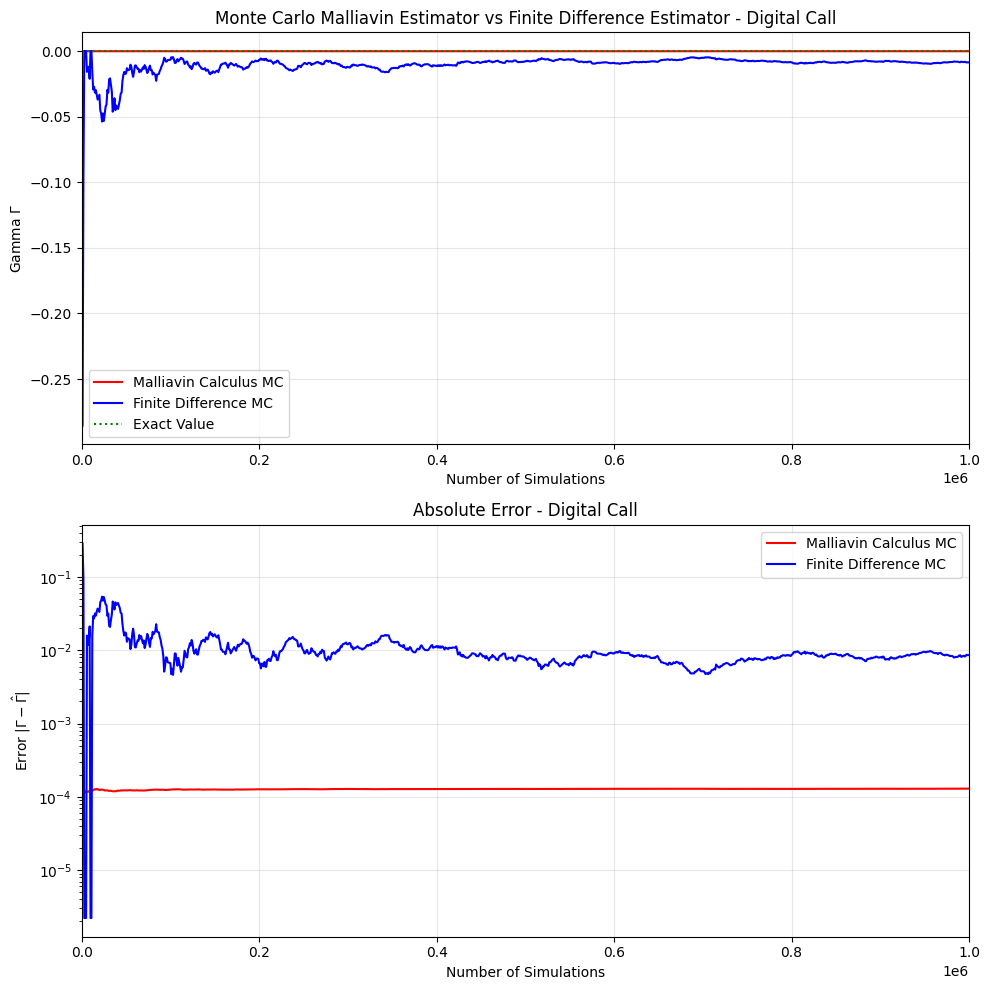

In [71]:
sizes, fd_gammas = gamma_fd(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_gammas = gamma_malliavin(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N)
digital_call_gamma = digital_call_gamma_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"{'Gamma for Digital Call':<53} = {digital_call_gamma:10.8f}")
print(f"{'Gamma for Digital Call by Finite Differences Estimator':<53} = {fd_gammas[-1]:10.8f}")
print(f"{'Gamma for Digital Call by MC Malliavin Estimator':<53} = {malliavin_gammas[-1]:10.8f}")


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

ax[0].plot(sizes, malliavin_gammas, color="red", label="Malliavin Calculus MC")
ax[0].plot(sizes, fd_gammas, color="blue", label="Finite Difference MC")
ax[0].hlines(digital_call_gamma, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
ax[0].set_xlim([0.0, sizes[-1]])
ax[0].set_ylabel(r"Gamma $\Gamma$")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator - Digital Call")
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)

ax[1].plot(sizes, np.abs(malliavin_gammas - digital_call_gamma), color="red", label="Malliavin Calculus MC")
ax[1].plot(sizes, np.abs(fd_gammas - digital_call_gamma), color="blue", label="Finite Difference MC")
ax[1].set_xlim([0.0, sizes[-1]])
ax[1].set_yscale('log')
ax[1].set_ylabel(r"Error $|\Gamma - \hat{\Gamma}|$")
ax[1].set_xlabel("Number of Simulations")
ax[1].set_title("Absolute Error - Digital Call")
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This experiment illustrates a total breakdown of the Finite Difference method. Because the second derivative of a step function involves derivatives of the Dirac distribution, the finite difference ratio yields meaningless results. Conversely, the Malliavin Calculus estimator, by transferring both differentiations to the underlying Gaussian density, successfully captures the correct negative sign and order of magnitude $\approx -0.000132$, proving to be the only mathematically sound approach among the two for second-order discontinuous Greeks. 

### References:

* Benhamou, Eric. *An application of malliavin calculus to continuous time asian options greeks*. SSRN, 2001.
* Pascucci, Andrea. *PDE and martingale methods in option pricing*. Vol. 2. Berlin: Springer, 2011.
* Rachev, Svetlozar Todorov. *Handbook of computational and numerical methods in finance*. Springer Science & Business Media, 2004.
* Zhong, Haixia, and Thomas Cass. *Malliavin calculus applied to Monte Carlo methods in mathematical finance*. Diss. Master’s thesis, Imperial College London, 2017.